<a href="https://colab.research.google.com/github/dilaramelek/veri-analizi-yolculugum/blob/main/gun2_pandas_giris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Gün 2 — Pandas'a Giriş
# Bugün: Kendi harcama verimizi oluşturup analiz edeceğiz

import pandas as pd

print("✅ Pandas yüklendi!")
print(f"Pandas versiyonu: {pd.__version__}")

✅ Pandas yüklendi!
Pandas versiyonu: 2.2.2


In [2]:
# Kendi aylık harcama verimizi oluşturuyoruz
# Bunlar örnek — kendi rakamlarınla değiştirebilirsin

harcamalar = {
    "Kategori": ["Kira", "Market", "Ulaşım", "Kafe", "Giyim", "Faturalar", "Eğlence"],
    "Tutar":    [8000,   3500,     800,      600,    1200,    1500,         500],
    "Zorunlu":  [True,   True,     True,     False,  False,   True,         False]
}

df = pd.DataFrame(harcamalar)
print(df)

    Kategori  Tutar  Zorunlu
0       Kira   8000     True
1     Market   3500     True
2     Ulaşım    800     True
3       Kafe    600    False
4      Giyim   1200    False
5  Faturalar   1500     True
6    Eğlence    500    False


In [3]:
# Toplam ne kadar harcadık?
toplam = df["Tutar"].sum()
print(f"💸 Toplam harcama: {toplam:,} TL")

# En pahalı harcama hangisi?
en_pahali = df.loc[df["Tutar"].idxmax()]
print(f"\n🔺 En pahalı harcama: {en_pahali['Kategori']} — {en_pahali['Tutar']:,} TL")

# En ucuz harcama hangisi?
en_ucuz = df.loc[df["Tutar"].idxmin()]
print(f"🔻 En ucuz harcama: {en_ucuz['Kategori']} — {en_ucuz['Tutar']:,} TL")

# Ortalama harcama nedir?
ortalama = df["Tutar"].mean()
print(f"\n📊 Ortalama harcama: {ortalama:,.0f} TL")

💸 Toplam harcama: 16,100 TL

🔺 En pahalı harcama: Kira — 8,000 TL
🔻 En ucuz harcama: Eğlence — 500 TL

📊 Ortalama harcama: 2,300 TL


In [4]:
# Zorunlu harcamalar
zorunlu = df[df["Zorunlu"] == True]
zorunlu_toplam = zorunlu["Tutar"].sum()

# Zorunlu olmayan harcamalar
gereksiz = df[df["Zorunlu"] == False]
gereksiz_toplam = gereksiz["Tutar"].sum()

# Yüzdeler
zorunlu_yuzde = (zorunlu_toplam / toplam) * 100
gereksiz_yuzde = (gereksiz_toplam / toplam) * 100

print("📊 HARCAMA ANALİZİ")
print("=" * 35)
print(f"✅ Zorunlu harcamalar:     {zorunlu_toplam:,} TL  (%{zorunlu_yuzde:.0f})")
print(f"⚠️  Zorunlu olmayan:        {gereksiz_toplam:,} TL   (%{gereksiz_yuzde:.0f})")
print(f"💸 Toplam:                 {toplam:,} TL")
print("=" * 35)

print("\n⚠️ Kısılabilecek harcamalar:")
print(gereksiz[["Kategori", "Tutar"]].to_string(index=False))

📊 HARCAMA ANALİZİ
✅ Zorunlu harcamalar:     13,800 TL  (%86)
⚠️  Zorunlu olmayan:        2,300 TL   (%14)
💸 Toplam:                 16,100 TL

⚠️ Kısılabilecek harcamalar:
Kategori  Tutar
    Kafe    600
   Giyim   1200
 Eğlence    500


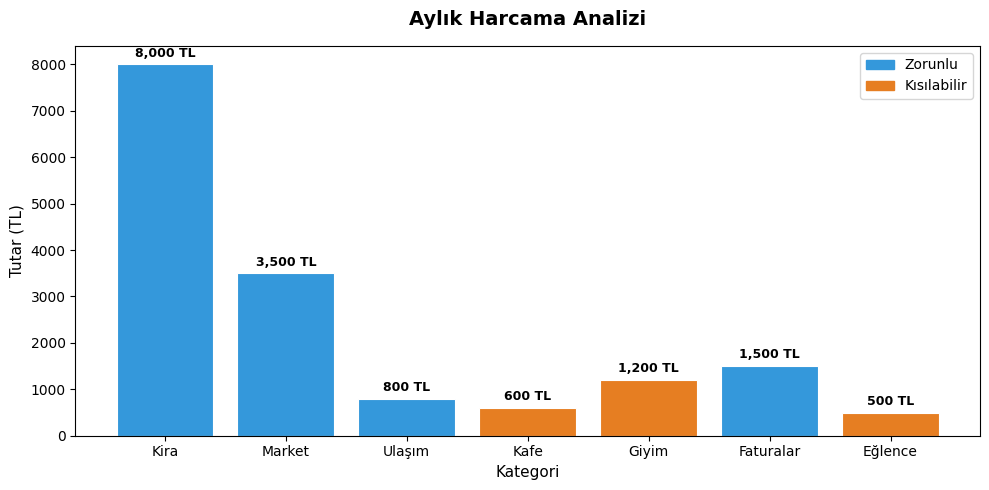

✅ Grafik kaydedildi: harcama_analizi.png


In [5]:
import matplotlib.pyplot as plt

# Renkleri belirle — zorunlu=mavi, değil=turuncu
renkler = ["#3498db" if z else "#e67e22" for z in df["Zorunlu"]]

# Grafik
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(df["Kategori"], df["Tutar"], color=renkler, edgecolor="white", linewidth=0.8)

# Her çubuğun üstüne rakam yaz
for bar, tutar in zip(bars, df["Tutar"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{tutar:,} TL", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Başlık ve etiketler
ax.set_title("Aylık Harcama Analizi", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Kategori", fontsize=11)
ax.set_ylabel("Tutar (TL)", fontsize=11)

# Açıklama kutusu
from matplotlib.patches import Patch
legend = [Patch(color="#3498db", label="Zorunlu"),
          Patch(color="#e67e22", label="Kısılabilir")]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.savefig("harcama_analizi.png", dpi=150)
plt.show()

print("✅ Grafik kaydedildi: harcama_analizi.png")
